# 1. Harris County Median Income Map

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('income_data.csv')
df

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,1400000US48201100001,Census Tract 1000.01; Harris County; Texas,3379,564,1767,477,785,379,0,21,...,89554,57312,"250,000+",***,90811,37795,83994,55270,-,**
2,1400000US48201210400,Census Tract 2104; Harris County; Texas,1475,198,325,113,277,111,49,60,...,58295,41148,-,**,44115,21129,43490,27101,56000,41680
3,1400000US48201210500,Census Tract 2105; Harris County; Texas,1932,214,556,149,200,199,20,28,...,"2,500-",***,76940,33304,56800,23197,55726,42532,113042,99817
4,1400000US48201210600,Census Tract 2106; Harris County; Texas,2375,483,1083,322,4,13,15,24,...,21408,1122,176584,105067,49953,35894,48386,26132,202938,125864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,1400000US48201980100,Census Tract 9801; Harris County; Texas,0,15,0,15,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**
1112,1400000US48201980200,Census Tract 9802; Harris County; Texas,145,56,27,24,75,50,0,21,...,-,**,-,**,101339,54166,101339,54166,-,**
1113,1400000US48201980300,Census Tract 9803; Harris County; Texas,5,7,5,7,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**
1114,1400000US48201980400,Census Tract 9804; Harris County; Texas,0,15,0,15,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**


In [3]:
import shapely
import numpy as np
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

import os
os.listdir()

['ACSST5Y2024.S0802-Data.csv',
 'ACSST5Y2024.S1903-Data.csv',
 'ACSST5Y2024.S2201-Data.csv',
 'harris_county_heat_maps.ipynb',
 'income_data.csv',
 'snap_data.csv',
 'tl_2024_48_tract.cpg',
 'tl_2024_48_tract.dbf',
 'tl_2024_48_tract.prj',
 'tl_2024_48_tract.shp',
 'tl_2024_48_tract.shp.ea.iso.xml',
 'tl_2024_48_tract.shp.iso.xml',
 'tl_2024_48_tract.shx',
 'vehicle_data.csv']

In [4]:
gdf = gpd.read_file("tl_2024_48_tract.shp")

In [5]:
harris = gdf[gdf["COUNTYFP"] == "201"]

In [6]:
merged = harris.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [7]:
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

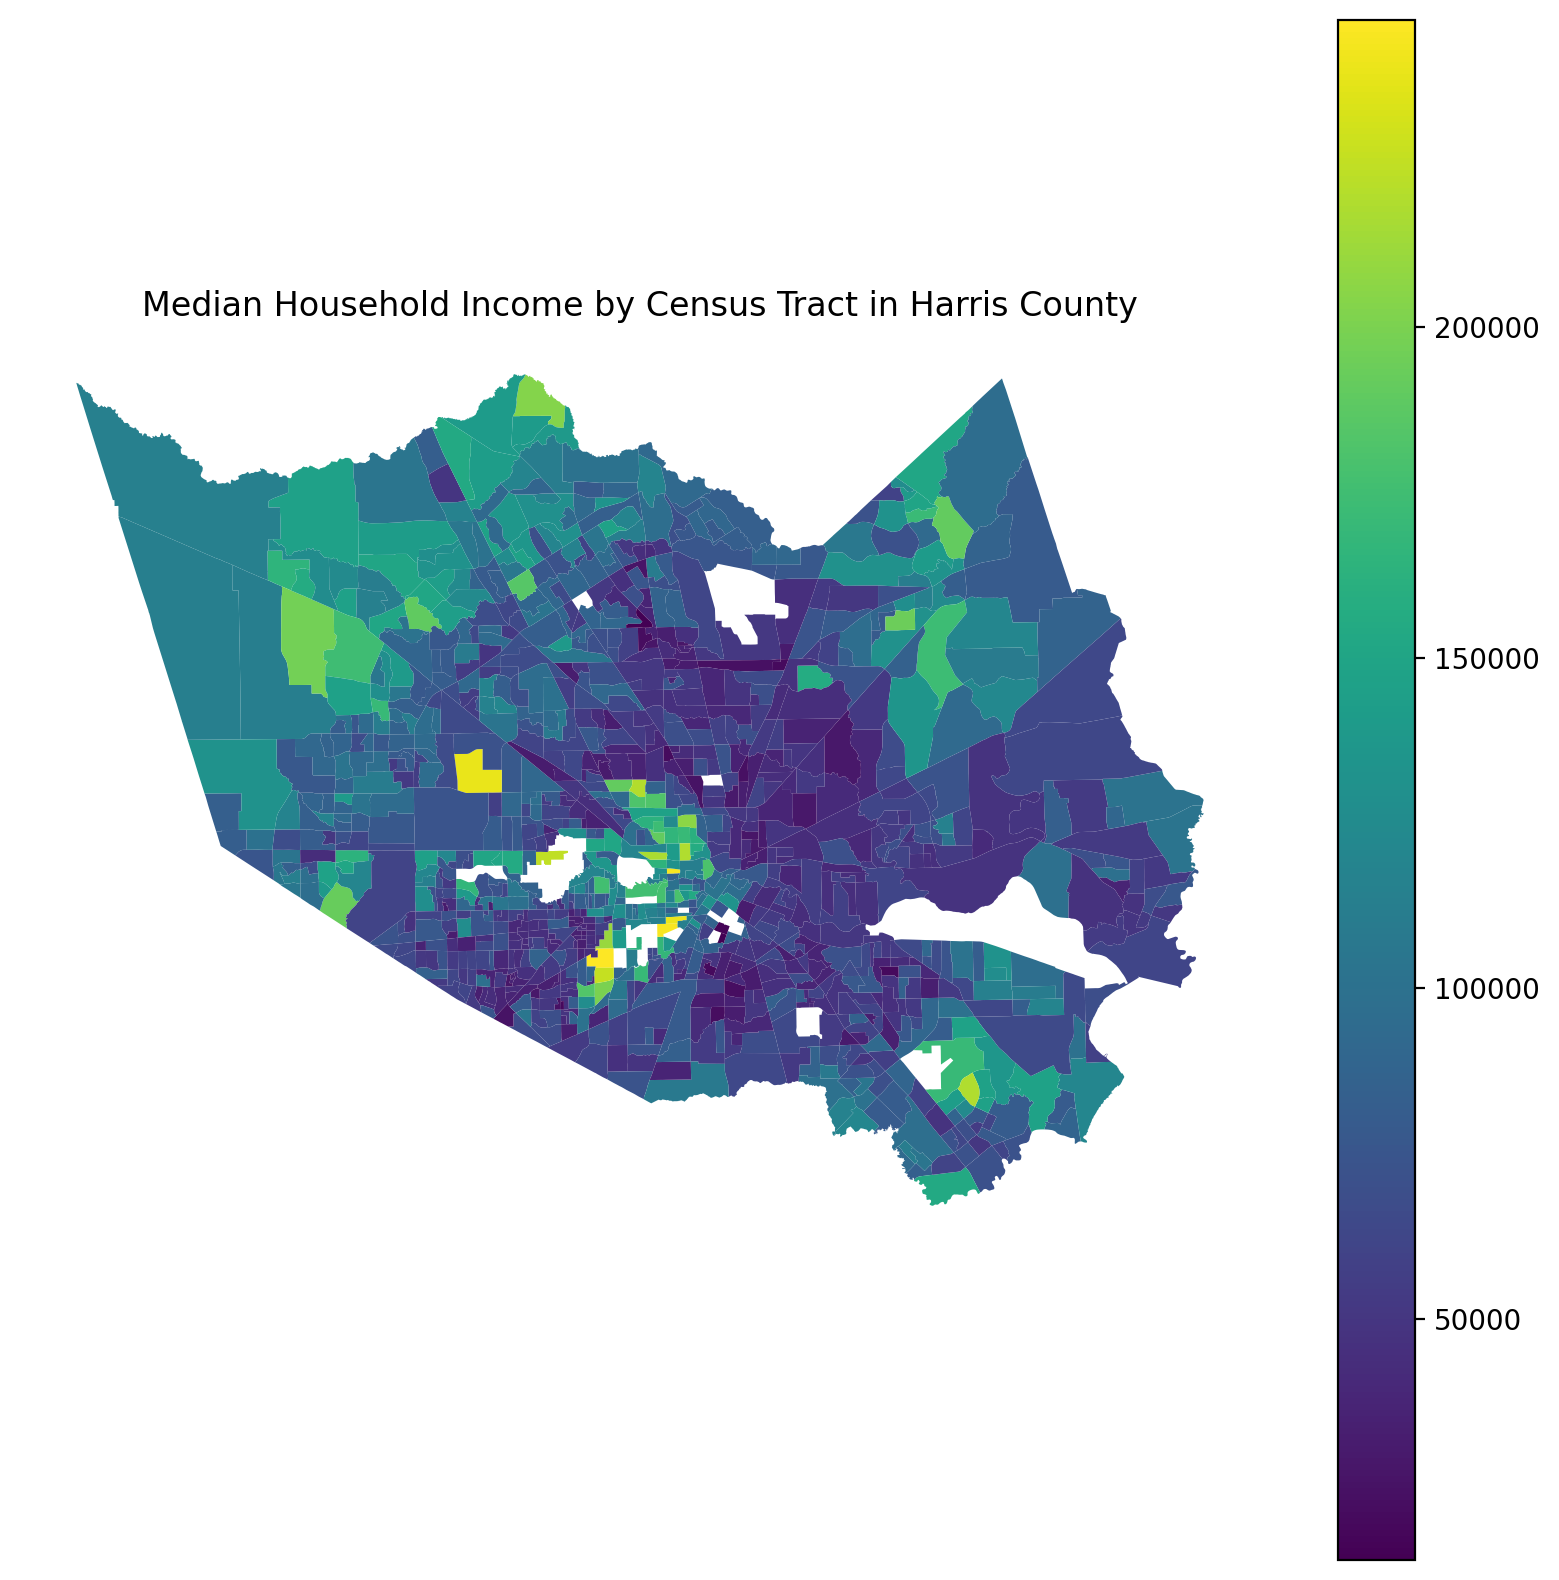

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="S1903_C03_001E",
    cmap="viridis",
    legend=True,
    ax=ax
)

plt.title("Median Household Income by Census Tract in Harris County")
plt.axis("off")
plt.show()

# 2. Mobility Map (No Vehicle Acces)

In [9]:
df = pd.read_csv('vehicle_data.csv')
df

C:\Users\saraz\AppData\Local\Temp\ipykernel_25424\3869483300.py:1: DtypeWarning: Columns (2,3,56,57,76,77,84,85,140,141,182,183,204,205,258,259,278,279,286,287,342,343,384,385,406,407,460,461,480,481,488,489,544,545,586,587,608,609,662,663,682,683,690,691,746,747,788,789,810,811,864,865,884,885,892,893,990,991) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('vehicle_data.csv')


,GEO_ID,NAME,S0802_C01_001E,S0802_C01_001M,S0802_C01_002E,S0802_C01_002M,S0802_C01_003E,S0802_C01_003M,S0802_C01_004E,S0802_C01_004M,...,S0802_C05_097E,S0802_C05_097M,S0802_C05_098E,S0802_C05_098M,S0802_C05_099E,S0802_C05_099M,S0802_C05_100E,S0802_C05_100M,S0802_C05_101E,S0802_C05_101M
0,Geography,Geographic Area Name,Estimate!!Total!!Workers 16 years and over,Margin of Error!!Total!!Workers 16 years and over,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,...,Estimate!!Worked from home!!Workers 16 years a...,Margin of Error!!Worked from home!!Workers 16 ...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...
1,1400000US48201100001,Census Tract 1000.01; Harris County; Texas,3680,677,0.2,0.3,9,6.3,69.5,10.5,...,0,5,(X),(X),(X),(X),(X),(X),(X),(X)
2,1400000US48201210400,Census Tract 2104; Harris County; Texas,1876,334,6.6,4.7,16.4,7.7,39.3,9.9,...,10.5,12.1,(X),(X),(X),(X),(X),(X),(X),(X)
3,1400000US48201210500,Census Tract 2105; Harris County; Texas,1821,314,0,2.7,10.2,6.2,42.1,10.1,...,28.6,24.6,(X),(X),(X),(X),(X),(X),(X),(X)
4,1400000US48201210600,Census Tract 2106; Harris County; Texas,2838,522,0.4,0.7,0.1,0.8,51.2,12,...,7.7,7.8,(X),(X),(X),(X),(X),(X),(X),(X)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,1400000US48201980100,Census Tract 9801; Harris County; Texas,0,15,-,**,-,**,-,**,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)
1112,1400000US48201980200,Census Tract 9802; Harris County; Texas,128,58,0,31.2,0,31.2,68,27,...,0,100,(X),(X),(X),(X),(X),(X),(X),(X)
1113,1400000US48201980300,Census Tract 9803; Harris County; Texas,745,159,24.8,10.4,67.8,10.7,7.4,8.4,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)
1114,1400000US48201980400,Census Tract 9804; Harris County; Texas,1188,298,25.8,13,65.2,12,8.9,7.1,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)


In [10]:
merged_2 = harris.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [11]:
merged_2["S0802_C01_094E"] = pd.to_numeric(
    merged_2["S0802_C01_094E"],
    errors="coerce"
)

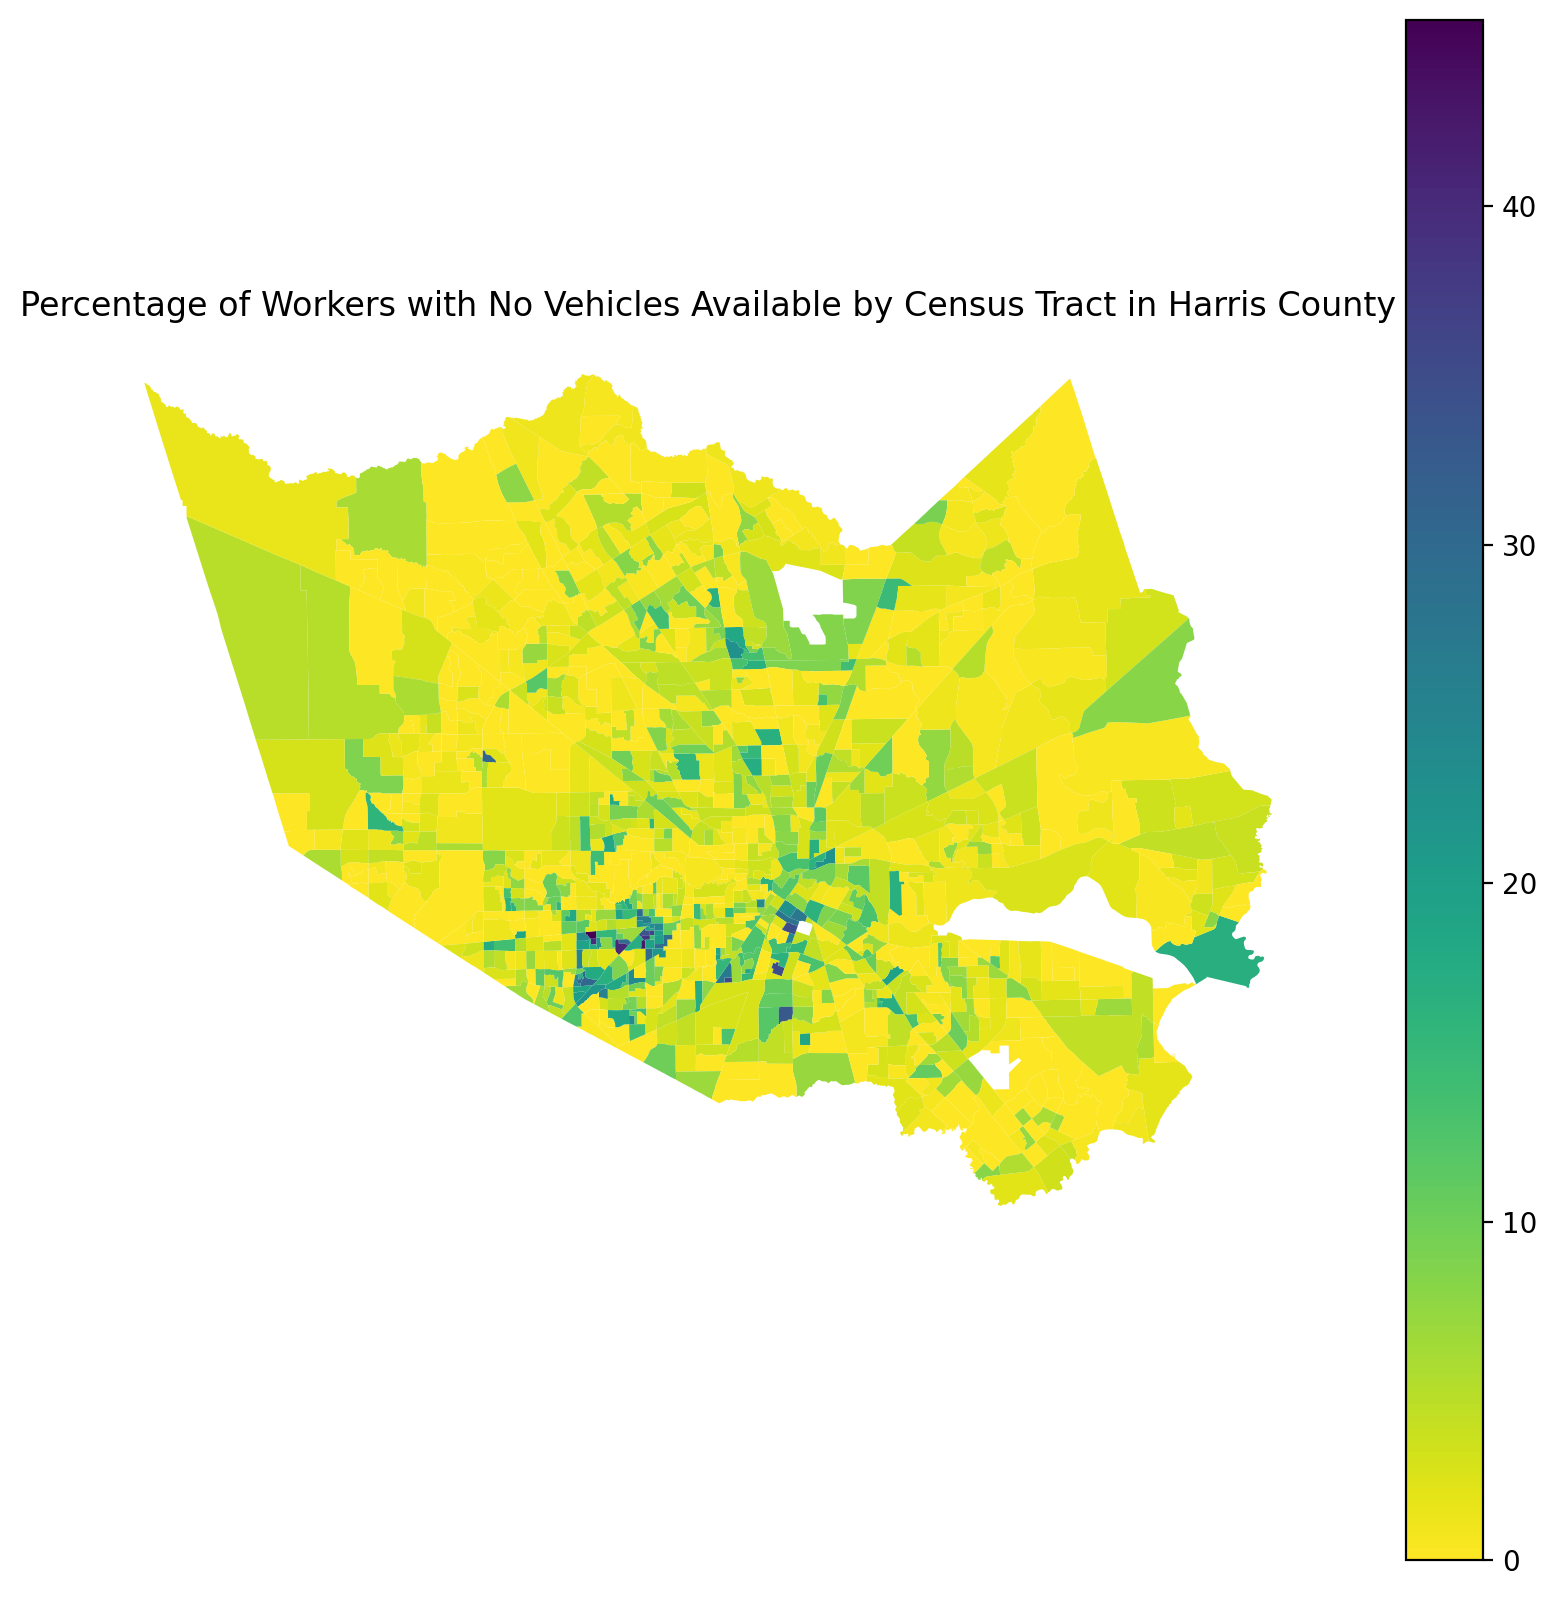

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_2.plot(
    column="S0802_C01_094E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of Workers with No Vehicles Available by Census Tract in Harris County")
plt.axis("off")
plt.show()

# 3. SNAP Map

In [13]:
df = pd.read_csv('snap_data.csv')
df

,GEO_ID,NAME,S2201_C01_001E,S2201_C01_001M,S2201_C01_002E,S2201_C01_002M,S2201_C01_003E,S2201_C01_003M,S2201_C01_004E,S2201_C01_004M,...,S2201_C06_034E,S2201_C06_034M,S2201_C06_035E,S2201_C06_035M,S2201_C06_036E,S2201_C06_036M,S2201_C06_037E,S2201_C06_037M,S2201_C06_038E,S2201_C06_038M
0,Geography,Geographic Area Name,Estimate!!Total!!Households,Margin of Error!!Total!!Households,Estimate!!Total!!Households!!With one or more ...,Margin of Error!!Total!!Households!!With one o...,Estimate!!Total!!Households!!No people in the ...,Margin of Error!!Total!!Households!!No people ...,Estimate!!Total!!Households!!Married-couple fa...,Margin of Error!!Total!!Households!!Married-co...,...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...
1,1400000US48201100001,Census Tract 1000.01; Harris County; Texas,3379,564,181,120,3198,558,489,265,...,(X),(X),(X),(X),0,8.6,55.7,23.4,44.3,23.4
2,1400000US48201210400,Census Tract 2104; Harris County; Texas,1475,198,682,200,793,177,488,121,...,(X),(X),(X),(X),6.8,6.1,22.6,9.5,70.7,10.6
3,1400000US48201210500,Census Tract 2105; Harris County; Texas,1932,214,1129,258,803,209,646,214,...,(X),(X),(X),(X),9.2,7.9,46.2,14.5,44.6,13.9
4,1400000US48201210600,Census Tract 2106; Harris County; Texas,2375,483,1065,481,1310,247,860,267,...,(X),(X),(X),(X),13.4,13.6,52.8,24,33.8,19.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,1400000US48201980100,Census Tract 9801; Harris County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**
1112,1400000US48201980200,Census Tract 9802; Harris County; Texas,145,56,8,6,137,57,5,8,...,(X),(X),(X),(X),0,84.4,73.7,53.4,26.3,53.4
1113,1400000US48201980300,Census Tract 9803; Harris County; Texas,5,7,0,15,5,7,5,7,...,(X),(X),(X),(X),0,100,0,100,100,100
1114,1400000US48201980400,Census Tract 9804; Harris County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**


In [14]:
merged_3 = harris.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

merged_3["S2201_C04_001E"] = pd.to_numeric(
    merged_3["S2201_C04_001E"],
    errors="coerce"
)

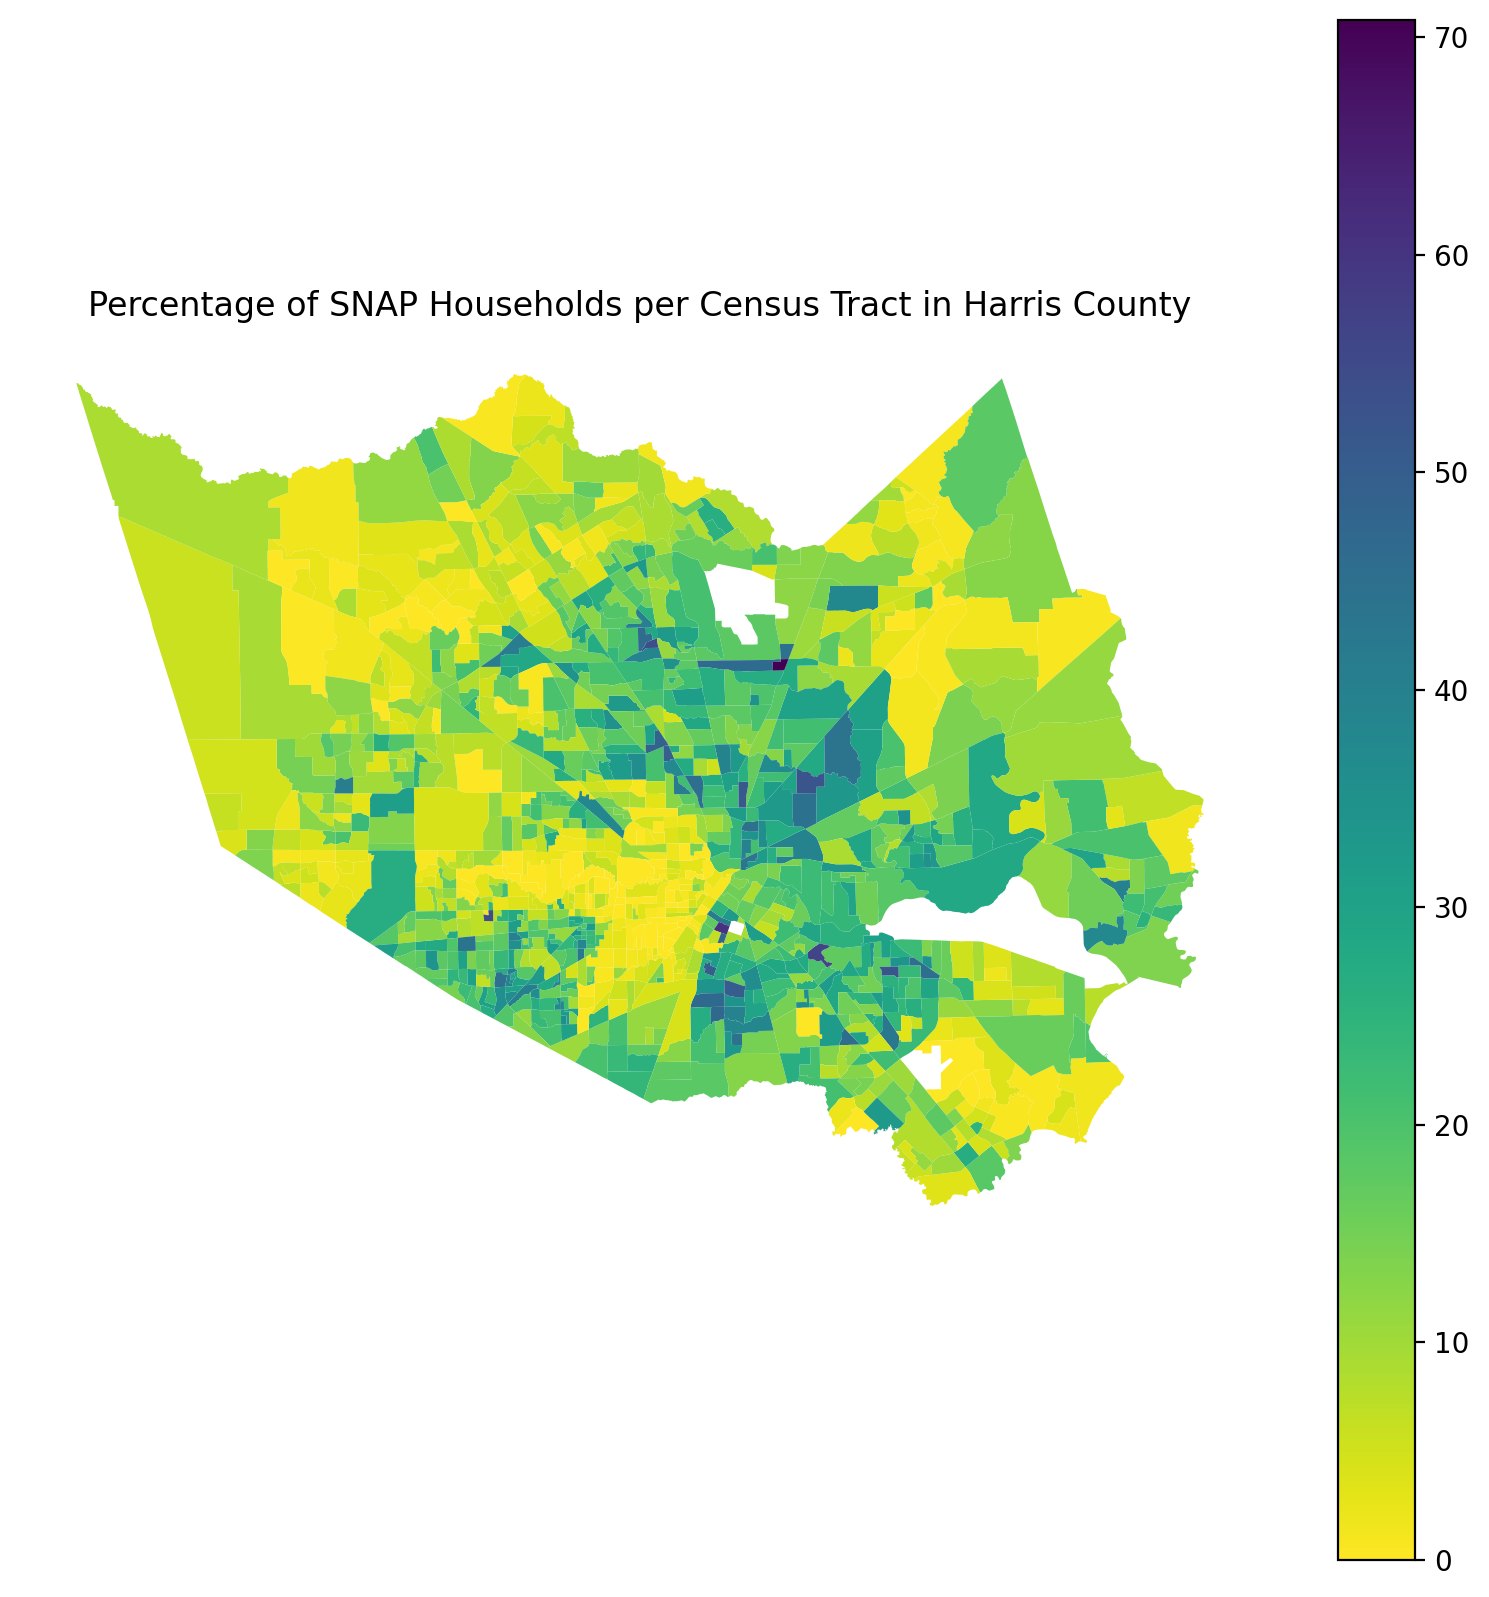

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_3.plot(
    column="S2201_C04_001E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of SNAP Households per Census Tract in Harris County")
plt.axis("off")
plt.show()